In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('exchange_rate.csv')

In [27]:
df.head(10)

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849
5,06-01-1990 00:00,0.7866
6,07-01-1990 00:00,0.7886
7,08-01-1990 00:00,0.7910
8,09-01-1990 00:00,0.7939
9,10-01-1990 00:00,0.7894


In [28]:
df.shape

(7588, 2)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [30]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [76]:
df.isna().sum()

Ex_rate    0
dtype: int64

there are no missing values in the dataset so no imputation was required

In [31]:
df['date'] = pd.to_datetime(df['date'],format= 'mixed',dayfirst=True)
df.set_index('date',inplace=True)

In [35]:
df.index

DatetimeIndex(['1990-01-01', '1990-01-02', '1990-01-03', '1990-01-04',
               '1990-01-05', '1990-01-06', '1990-01-07', '1990-01-08',
               '1990-01-09', '1990-01-10',
               ...
               '2010-10-01', '2010-10-02', '2010-10-03', '2010-10-04',
               '2010-10-05', '2010-10-06', '2010-10-07', '2010-10-08',
               '2010-10-09', '2010-10-10'],
              dtype='datetime64[ns]', name='date', length=7588, freq=None)

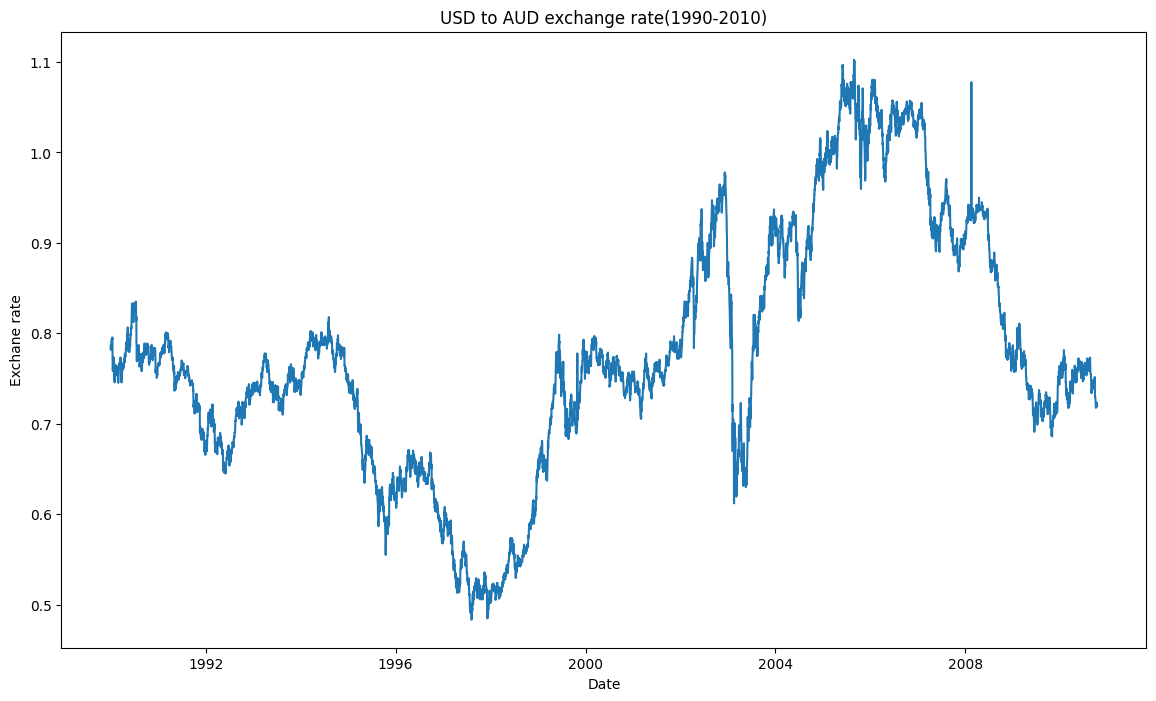

In [39]:
plt.figure(figsize=(14,8))
plt.plot(df.index,df.iloc[:,0])
plt.title('USD to AUD exchange rate(1990-2010)')
plt.xlabel('Date')
plt.ylabel('Exchane rate')
plt.show()

In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])
print('ADF Statistic:',result[0])
print('P-value:',result[1])

for key,value in result[4].items():
    print(f'critical value ({key}):{value}')

ADF Statistic: -1.6649941807381512
P-value: 0.44923273535979097
critical value (1%):-3.4312123140180137
critical value (5%):-2.861921078147796
critical value (10%):-2.5669728434336108


from the analysis the series is not stationary this matches the financial time series behaviour.

In [41]:
df_diff = df.iloc[:,0].diff()
df_diff.head()

date
1990-01-01       NaN
1990-01-02   -0.0037
1990-01-03    0.0049
1990-01-04   -0.0007
1990-01-05   -0.0011
Name: Ex_rate, dtype: float64

In [42]:
# dropping the NaN
df_diff = df_diff.dropna()

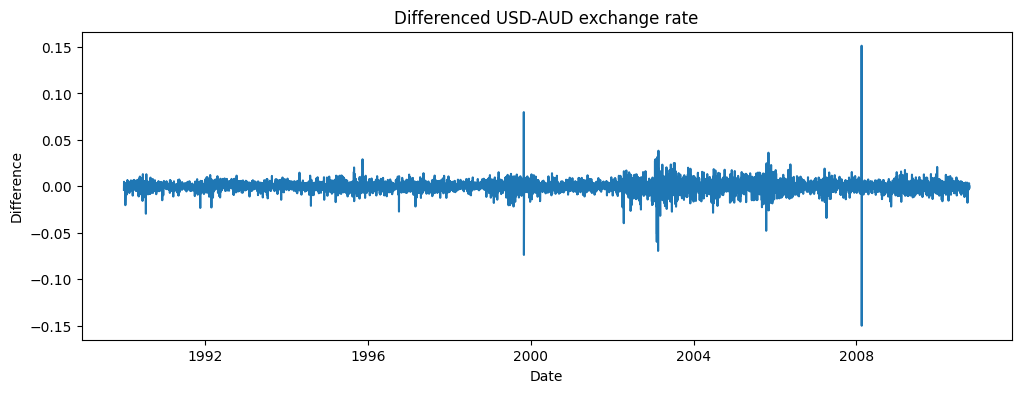

In [43]:
plt.figure(figsize=(12,4))
plt.plot(df_diff)
plt.title('Differenced USD-AUD exchange rate')
plt.xlabel('Date')
plt.ylabel('Difference')
plt.show()

In [44]:
result_diff = adfuller(df_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

for key, value in result_diff[4].items():
    print(f"Critical Value ({key}): {value}")


ADF Statistic: -99.39343120118629
p-value: 0.0
Critical Value (1%): -3.4312123140180137
Critical Value (5%): -2.861921078147796
Critical Value (10%): -2.5669728434336108


after first order differencing the time series becomes stationary.

<Figure size 1200x600 with 0 Axes>

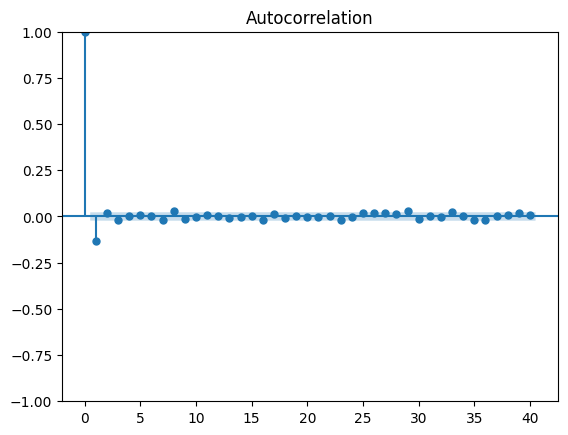

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ploting ACF
plt.figure(figsize=(12,6))
plot_acf(df_diff, lags=40)
plt.show()

<Figure size 1200x600 with 0 Axes>

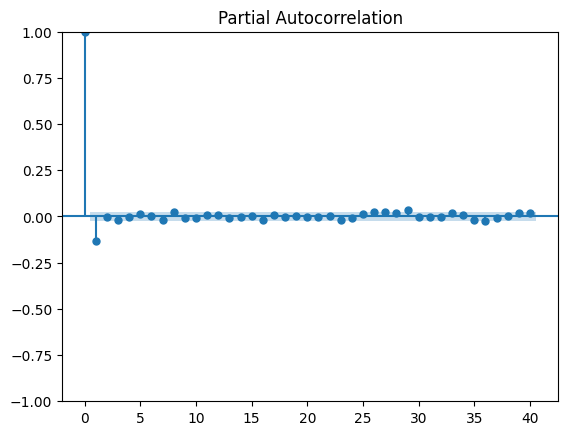

In [50]:
# plotting PACF
plt.figure(figsize=(12,6))
plot_pacf(df_diff,lags=40)
plt.show()

The ACF plot of the differenced series shows a significant spike at lag 1 followed by values within the confidence interval. This indicates that the moving average component cuts off after lag 1, suggesting an MA(1) component (q = 1).
The PACF plot shows a significant spike at lag 1 and no significant spikes afterwards. This suggests the presence of an AR(1) component (p = 1).

Based on these observations, the ARIMA(1,1,1) model was selected for forecasting.

# Baseline Arima model

In [51]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df.iloc[:,0], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 06 Feb 2026   AIC                         -56102.322
Time:                        20:53:39   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

The AR(1) coefficient is statistically significant (p-value = 0.005), indicating that past values of the exchange rate have a meaningful influence on current values. However, the MA(1) coefficient is not statistically significant (p-value = 0.920), suggesting that the moving average component may not contribute significantly to the model.

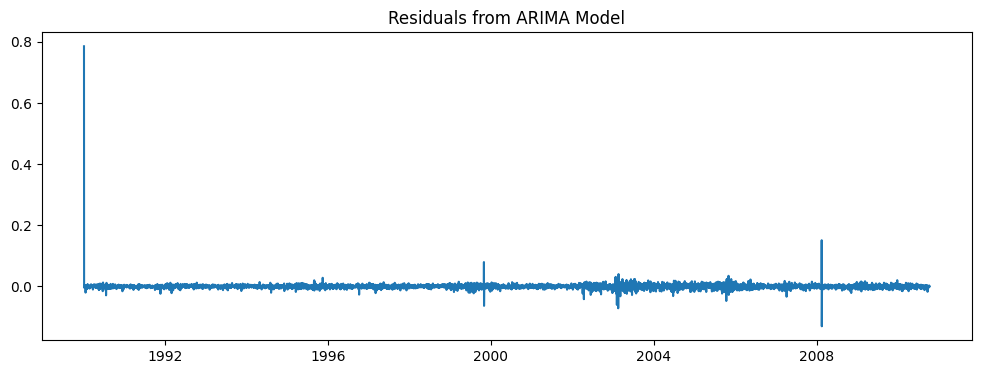

In [52]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals from ARIMA Model")
plt.show()


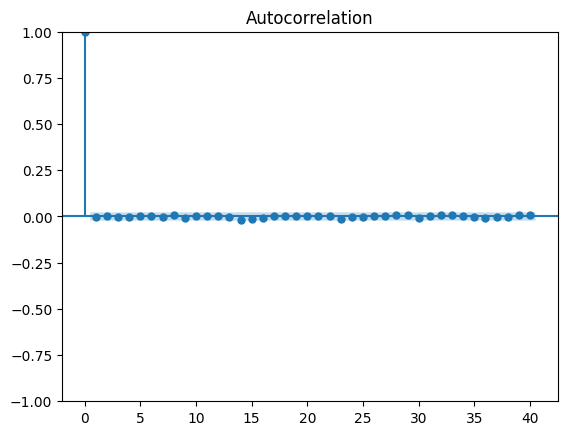

In [53]:
plot_acf(residuals,lags=40)
plt.show()

The residual time plot shows that the errors fluctuate randomly around zero with no visible trend or repeating patterns. This indicates that the ARIMA model has captured most of the structure present in the time series.
The ACF plot of residuals shows that all autocorrelation values lie within the confidence interval. This suggests that no significant autocorrelation remains in the residuals, confirming that the ARIMA model has adequately captured the temporal dependencies in the data.

In [54]:
train =df.iloc[:-365]
test = df.iloc[-365:]

print(train.shape)
print(test.shape)

(7223, 1)
(365, 1)


# Model -Arima

In [55]:
model_Arima = ARIMA(train.iloc[:,0], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 06 Feb 2026   AIC                         -56102.322
Time:                        22:12:43   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

In [56]:
forecast = model_fit.forecast(steps =len(test))

In [57]:
forecast

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
                ...   
2011-10-06    0.720826
2011-10-07    0.720826
2011-10-08    0.720826
2011-10-09    0.720826
2011-10-10    0.720826
Freq: D, Name: predicted_mean, Length: 365, dtype: float64

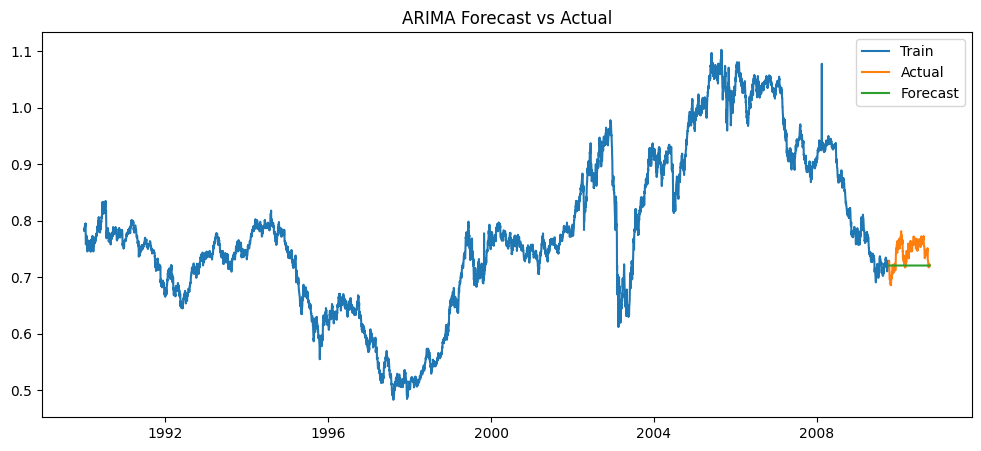

In [58]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train.iloc[:,0], label="Train")
plt.plot(test.index, test.iloc[:,0], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test.iloc[:,0], forecast)
rmse = np.sqrt(mean_squared_error(test.iloc[:,0], forecast))
mape = np.mean(np.abs((test.iloc[:,0] - forecast) / test.iloc[:,0])) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE : 0.027569160177337623
RMSE: 0.03128810564908311
MAPE: nan


Exchange rate dataset somtimes contain 0 values that breaks MAPE. Thats why it is showing NaN

In [61]:
actual = test.iloc[:,0].values
pred = forecast

mask = actual !=0
mape = np.mean(np.abs((actual[mask]-pred[mask]) /  actual[mask])) * 100

print('Fixed MAPE:', mape)

Fixed MAPE: 3.663847426235461


For a forecasting model this is a good mape score. since it is lower than 3.66, it is considered strong forecasting performance.

# Model Building - Exponential smoothing

model shows long term trend but no clear seasonality. Holt's linear exponential smoothing model will be appropriate to use here.

In [62]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(
                train.iloc[:,0],
                trend = 'add',
                seasonal =None).fit()

print(holt_model.summary())

C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7223
Model:             ExponentialSmoothing   SSE                              0.265
Optimized:                         True   AIC                         -73758.947
Trend:                         Additive   BIC                         -73731.407
Seasonal:                          None   AICC                        -73758.936
Seasonal Periods:                  None   Date:                 Sat, 07 Feb 2026
Box-Cox:                          False   Time:                         11:01:23
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8686552                alpha                 True
smoothing_trend             0.0000

In [63]:
holt_forecast = holt_model.forecast(steps=len(test))

In [64]:
holt_forecast

2009-10-11    0.728461
2009-10-12    0.728453
2009-10-13    0.728445
2009-10-14    0.728437
2009-10-15    0.728429
                ...   
2010-10-06    0.725634
2010-10-07    0.725626
2010-10-08    0.725618
2010-10-09    0.725610
2010-10-10    0.725602
Freq: D, Length: 365, dtype: float64

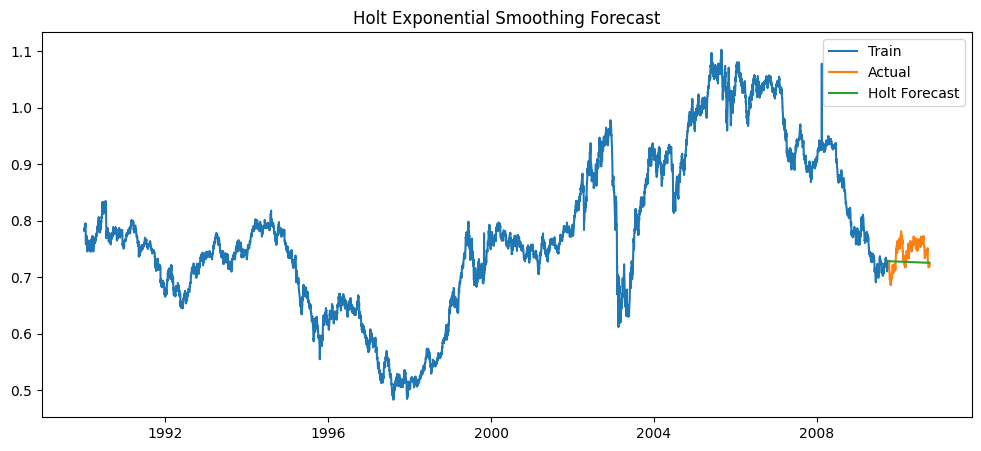

In [65]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train.iloc[:,0], label="Train")
plt.plot(test.index, test.iloc[:,0], label="Actual")
plt.plot(test.index, holt_forecast, label="Holt Forecast")

plt.title("Holt Exponential Smoothing Forecast")
plt.legend()
plt.show()


In [66]:
actual = test.iloc[:,0].values
pred = holt_forecast.values

mae_holt = mean_absolute_error(actual, pred)
rmse_holt = np.sqrt(mean_squared_error(actual, pred))

mask = actual != 0
mape_holt = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

print("Holt MAE :", mae_holt)
print("Holt RMSE:", rmse_holt)
print("Holt MAPE:", mape_holt)


Holt MAE : 0.024419567633932923
Holt RMSE: 0.027393392210619084
Holt MAPE: 3.257916485505087


The forecasting performance of ARIMA and Holt’s Exponential Smoothing models was compared using MAE, RMSE, and MAPE. The Holt model produced lower error values across all evaluation metrics. This indicates that Holt’s Linear Trend model captured the underlying trend in the exchange rate data more effectively than the ARIMA model.

# Optimized Holt's model with AIC

In [67]:
# grid search for best parameters for holt smoothing
alphas = np.arange(0.1, 1.0, 0.1)
betas = np.arange(0.1, 1.0, 0.1)

best_aic = float("inf")
best_params = None
best_model = None

for a in alphas:
    for b in betas:
        try:
            model = ExponentialSmoothing(
                train.iloc[:,0],
                trend='add',
                seasonal=None
            ).fit(
                smoothing_level=a,
                smoothing_trend=b,
                optimized=False
            )

            if model.aic < best_aic:
                best_aic = model.aic
                best_params = (a, b)
                best_model = model

        except:
            continue

print("Best alpha, beta:", best_params)
print("Best AIC:", best_aic)

C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Progra

C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Progra

C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Shree Hari\AppData\Local\Progra

Best alpha, beta: (0.8, 0.1)
Best AIC: -73405.31829725121


In [68]:
opt_holt_forecast = best_model.forecast(steps=len(test))

In [69]:
opt_holt_forecast

2009-10-11    0.728943
2009-10-12    0.729320
2009-10-13    0.729697
2009-10-14    0.730074
2009-10-15    0.730451
                ...   
2010-10-06    0.864696
2010-10-07    0.865073
2010-10-08    0.865450
2010-10-09    0.865827
2010-10-10    0.866204
Freq: D, Length: 365, dtype: float64

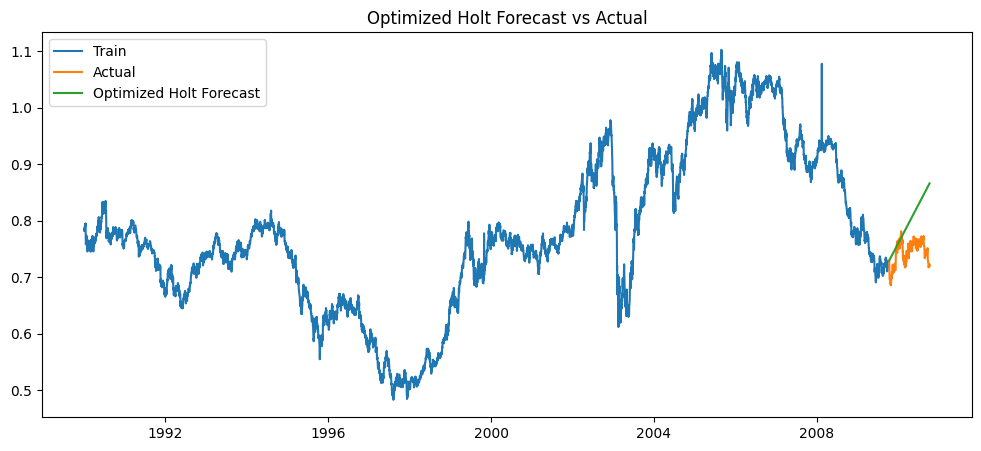

In [70]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train.iloc[:,0], label="Train")
plt.plot(test.index, test.iloc[:,0], label="Actual")
plt.plot(test.index, opt_holt_forecast, label="Optimized Holt Forecast")

plt.title("Optimized Holt Forecast vs Actual")
plt.legend()
plt.show()


In [71]:
actual = test.iloc[:,0].values
pred = opt_holt_forecast.values

mae_opt = mean_absolute_error(actual, pred)
rmse_opt = np.sqrt(mean_squared_error(actual, pred))

mask = actual != 0
mape_opt = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

print("Optimized Holt MAE :", mae_opt)
print("Optimized Holt RMSE:", rmse_opt)
print("Optimized Holt MAPE:", mape_opt)


Optimized Holt MAE : 0.05440105763132441
Optimized Holt RMSE: 0.06460061855314361
Optimized Holt MAPE: 7.330989669187181


A grid search was performed to optimize the smoothing parameters using AIC. Although the optimized model achieved a lower AIC value, its forecasting performance on the test set declined. This indicates overfitting, where the model fits historical data well but generalizes poorly to unseen data.

Advantages and Limitations:

ARIMA advantages:

        Captures autocorrelation structure,Strong theoretical foundation,Good for complex time dependencies

ARIMA limitations:
            
         Requires stationarity,Parameter tuning is complex,More sensitive to noise.

Exponential Smoothing advantages:
        
        Simple and fast,Works well for trend data,Fewer assumptions,

Exponential Smoothing limitations:
         
         Less flexible for complex patterns.

# Conclusion

Although parameter optimization reduced AIC, the optimized Holt model produced higher forecasting errors, indicating overfitting. The default Holt model provided the best balance between simplicity and forecasting accuracy. Therefore, Holt’s Linear Exponential Smoothing with default parameters is selected as the final forecasting model for this dataset.